In [54]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
# plt.rarams.update({'font.size': 16})

RUN = 2938

f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{RUN}.root")
df = ROOT.RDataFrame("coincidenceEvents", f)

df = df.Filter("isPulser == 0")

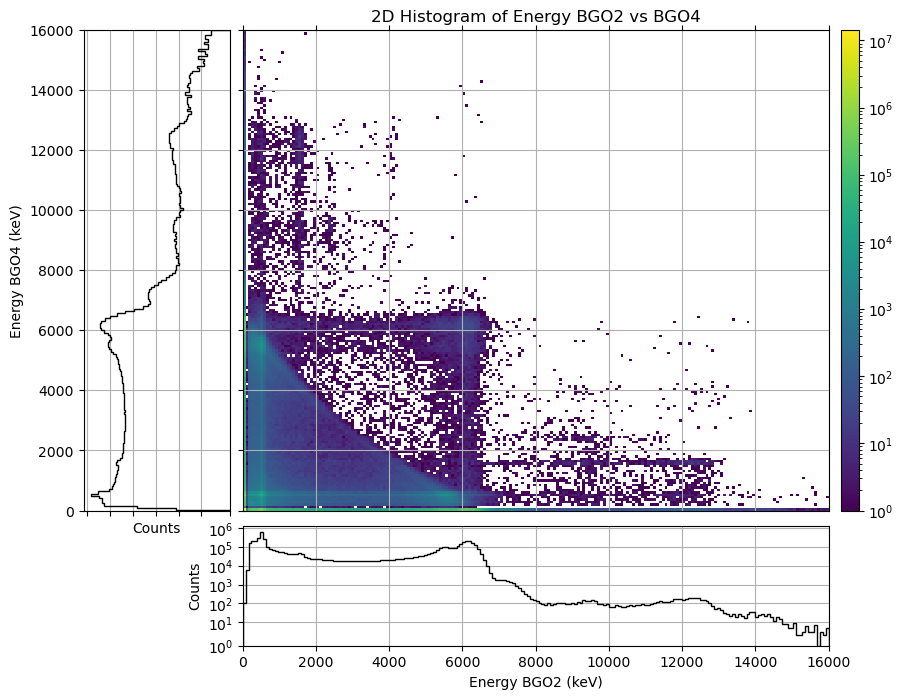

In [58]:
# 2D histogram of the non-gated spectra with marginal histograms

events = df.AsNumpy(columns=["energyBGO2", "energyBGO4"])

import matplotlib.colors as colors

def plot_events_hist2d_with_marginals(events, bins, range=None, cmap='viridis', hist_bins=None):
    x = events['energyBGO2']
    y = events['energyBGO4']
    if hist_bins is None:
        hist_bins = bins

    # Layout: 2 rows x 3 cols. Col 0 = left marginal (aligned with main),
    # Col 1 = main and bottom marginal, Col 2 = colorbar (aligned with main row only).
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 3, width_ratios=(1, 4, 0.12), height_ratios=(4, 1), wspace=0.05, hspace=0.05)
    ax_main = fig.add_subplot(gs[0, 1])
    ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
    # Left marginal should match the main 2D histogram vertical extent only
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    # Colorbar aligned with the main (top) row so it matches main height exactly
    ax_cbar = fig.add_subplot(gs[0, 2])

    # Main 2D histogram (log color scale)
    # Use LogNorm with vmin/vmax inside the norm (avoid passing vmin/vmax alongside norm)
    h = ax_main.hist2d(x, y, bins=bins, range=range, cmap=cmap, norm=colors.LogNorm())
    fig.colorbar(h[3], cax=ax_cbar)
    ax_main.set_title('2D Histogram of Energy BGO2 vs BGO4')
    ax_main.tick_params(axis='x', labeltop=False, labelbottom=False)
    ax_main.tick_params(axis='y', labelleft=False, labelright=False)
    ax_main.grid()

    # compute counts (same bins/ranges used for the plotted histograms)
    counts_x, _ = np.histogram(x, bins=bins, range=[1, 16000])
    counts_y, _ = np.histogram(y, bins=bins, range=[1, 16000])

    # take the greater non-zero value and enforce minimum 1 for symlog
    max_count = max(1, int(max(counts_x.max() if counts_x.size else 1,
                            counts_y.max() if counts_y.size else 1)))

    # Bottom marginal: distribution of x (energyBGO2), placed below main
    ax_bottom.hist(x, bins=bins, range=[1, 16000], color='black', histtype='step')
    ax_bottom.set_xlabel('Energy BGO2 (keV)')
    ax_bottom.set_ylabel('Counts')
    # Ensure bottom histogram x-limits match main and y-axis (counts) starts at 1 for symlog
    ax_bottom.set_xlim(ax_main.get_xlim())
    ax_bottom.set_yscale('symlog')
    ax_bottom.set_ylim(1, max_count*2)
    ax_bottom.tick_params(axis='x', rotation=0)
    ax_bottom.grid()

    # Left marginal: distribution of y (energyBGO4), placed to the left of main
    ax_left.hist(y, bins=bins, range=[1, 16000], orientation='horizontal', color='black', histtype='step')
    ax_left.set_ylabel('Energy BGO4 (keV)')
    ax_left.set_xlabel('Counts')
    # Match vertical extent to main and use symlog on counts axis, starting at 1
    ax_left.tick_params(axis='x', labeltop=False, labelbottom=False)
    ax_left.set_ylim(ax_main.get_ylim())
    ax_left.set_xscale('symlog')
    ax_left.set_xlim(1, max_count*2)
    ax_left.invert_xaxis()
    ax_left.grid()

    # Tidy ticks: main shows top x, bottom shows bottom x; left shares y with main
    ax_main.xaxis.tick_top()
    ax_bottom.xaxis.tick_bottom()
    ax_main.yaxis.tick_left()
    ax_left.yaxis.tick_left()

    plt.show()

# Call the plotting function
plot_events_hist2d_with_marginals(events, bins=200, range=[[0, 16000], [0, 16000]], cmap='viridis', hist_bins=200)


In [34]:
# 2D histogram of the gated spectra

from tqdm import tqdm

def plot_events_hist2d_gated(events, name, bins=500, range=None, cmap='viridis'):
    plt.figure(figsize=(8, 6))
    plt.hist2d(events['energyBGO2'], events['energyBGO4'], bins=bins, range=range, cmap=cmap, norm=colors.LogNorm())
    plt.colorbar(label='Counts')
    plt.xlabel('Energy BGO2 (keV)')
    plt.ylabel('Energy BGO4 (keV)')
    plt.title('2D Histogram of Energy BGO2 vs BGO4')
    plt.grid()
    plt.savefig(f"gif_plots/{name}.png", dpi=300, bbox_inches='tight')
    plt.close()

gates = list(np.arange(1000, 16000, 50))
for gate in tqdm(gates):
    gate_min, gate_max = gate, gate+1000
    df_gated = df.Filter(f"energySum > {gate_min} && energySum < {gate_max} && isPulser == 0 && deltaT < 10")
    events_gated = df_gated.AsNumpy(columns=["energyBGO2", "energyBGO4"])
    mask = (events_gated['energyBGO2'] < gate_min) & (events_gated['energyBGO4'] < gate_min)
    events_gated = {key: val[mask] for key, val in events_gated.items()}
    plot_events_hist2d_gated(events_gated, bins=200, range=[[0, 16000], [0, 16000]], cmap='viridis', name=f"{gates.index(gate)}")
    # print(f"Generated image for gate {gate_min} - {gate_max} keV")

# Generate a GIF from the saved images
import imageio
images = []
for gate in gates:
    filename = f"gif_plots/{gates.index(gate)}.png"
    images.append(imageio.imread(filename))
imageio.mimsave('energy_gates.gif', images, duration=30)